# 9-2 Seq2Seq 모델의 배치 학습

본 노트북은 9-2절 본문 예제 [코드 9-13]~[코드 9-18]을 모아 위에서 아래로
실행해 본다. 9-1절의 날짜 변환기 모델을 가변 길이 미니 배치 학습이 가능하도록
수정한다.

다루는 내용
- `<pad>`를 추가한 어휘 사전과 데이터셋 ([코드 9-13])
- 배치 병합 함수와 배치 데이터로더 ([코드 9-14])
- 패킹/언패킹을 적용한 인코더, 길이 정보 텐서 전달 ([코드 9-15]~[코드 9-17])
- `<pad>` 위치 손실을 무시하는 손실 함수와 미니 배치 학습 ([코드 9-18])

검증 함수와 학습 루프는 본문 미공개이므로 노트북에서 직접 정의한다.

In [ ]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# 9장 예제는 PyTorch 기본 패키지만으로 동작한다.
# !pip install -q matplotlib numpy torch

In [1]:
# 참고 - 공통 라이브러리 경로 설정
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

viz.configure(save_grayscale=False)

In [2]:
# 참고 - 시드 고정과 학습 장치 객체 생성
SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


## 데이터 생성 함수 (data.ipynb 본문 복사)

9-1절과 동일한 데이터 생성 함수로 4,000개의 (입력, 정답) 날짜 쌍을 만든다.

In [3]:
# 참고: 데이터 생성 함수 (9-1절과 동일)
from datetime import datetime, timedelta
import random

src_formats = [
    '%d %B %Y',     # 01 February 2026
    '%d %b %Y',     # 01 Feb 2026
    '%B %d, %Y',    # February 01, 2026
    '%b %d, %Y',    # Feb 01, 2026
    '%m/%d/%Y',     # 02/01/2026
    '%Y/%m/%d',     # 2026/02/01
    '%d-%m-%Y',     # 01-02-2026
    '%Y-%m-%d',     # 2026-02-01
]

# 시작일(start_date)과 종료일(end_date) 사이의 sample_size개의 무작위 날짜 선택
def choice_random_dates(sample_size=1, start_date=None, end_date=None):
    if start_date is None:
        start_date = datetime(1900, 1, 1)
    if end_date is None:
        end_date = datetime(2050, 12, 31)
    days_between = (end_date - start_date).days
    datetime_list = []
    for _ in range(sample_size):
        days_after = random.randrange(days_between)
        datetime_list.append(start_date + timedelta(days=days_after))
    return datetime_list

# datetime 리스트를 입력 리스트와 정답 리스트로 변환하는 함수
# 입력은 src_formats에 정의된 형식으로, 정답은 'YYYY-M-D' 형식으로 변환
def generate_datepairs(date_list, src_formats=src_formats):
    if len(src_formats) == 0:
        raise ValueError('입력 문자열 템플릿이 비어 있습니다.')
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(date.strftime(src_format))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates


# 4,000개의 (입력, 정답) 날짜 쌍 생성
date_list = choice_random_dates(4000)
src_dates, tgt_dates = generate_datepairs(date_list)
print(f'생성된 날짜 쌍의 수: {len(src_dates)}')

생성된 날짜 쌍의 수: 4000


## [코드 9-13] 배치 구성을 위한 어휘 사전과 데이터셋 수정

배치 패딩을 위해 어휘 사전에 `<pad>`를 추가하고, 텐서 변환을 배치 병합으로
미루기 위해 `__getitem__()`이 정수 리스트를 반환하도록 수정한다.

In [4]:
###############################################################################
# 코드 9-13 - 배치 구성을 위한 어휘 사전과 데이터셋
###############################################################################
from torch.utils.data import Dataset

# 특수 토큰 조합에 <pad> 추가
SOS_TOKEN, EOS_TOKEN, PAD_TOKEN = '<sos>', '<eos>', '<pad>'
SOS_IDX, EOS_IDX, PAD_IDX = 0, 1, 2
special_tokens = {SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX, PAD_TOKEN: PAD_IDX}

# 어휘 사전 클래스(Vocab)는 9-1절과 동일
class Vocab:
    def __init__(self, sequence_list, special_tokens):
        tokens = set()
        for sequence in sequence_list:
            tokens.update(sequence)
        self.vocab = dict(special_tokens)
        idx_start = len(special_tokens)
        for i, token in enumerate(sorted(tokens)):
            self.vocab[token] = i + idx_start
        self.itos = {idx: token for token, idx in self.vocab.items()}

    def encode(self, input_sequence):
        return [self.vocab[token] for token in input_sequence]

    def decode(self, input_ids):
        return [self.itos[idx] for idx in input_ids]

    def __len__(self):
        return len(self.vocab)

# 데이터셋 클래스
class DateDataset(Dataset):
    def __init__(self, src_dates, tgt_dates, src_vocab, tgt_vocab):
        self.samples = []
        for src_date, tgt_date in zip(src_dates, tgt_dates):
            src_ids = src_vocab.encode(src_date)
            tgt_ids = tgt_vocab.encode(tgt_date)
            tgt_ids = [SOS_IDX] + tgt_ids + [EOS_IDX]
            self.samples.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.samples)

    # 텐서 변환 없음 (데이터로더가 텐서로 변환해 모델에 전달)
    def __getitem__(self, idx):
        src_ids, tgt_ids = self.samples[idx]
        return src_ids, tgt_ids


src_vocab = Vocab(src_dates, special_tokens)
tgt_vocab = Vocab(tgt_dates, special_tokens)
train_set = DateDataset(src_dates[:3000], tgt_dates[:3000], src_vocab, tgt_vocab)
valid_set = DateDataset(src_dates[3000:], tgt_dates[3000:], src_vocab, tgt_vocab)
print(f'입력 어휘 사전 크기: {len(src_vocab)} (<pad> 포함)')
print(f'출력 어휘 사전 크기: {len(tgt_vocab)} (<pad> 포함)')

입력 어휘 사전 크기: 43 (<pad> 포함)
출력 어휘 사전 크기: 14 (<pad> 포함)


## [코드 9-14] 배치 병합 함수를 정의해 배치 데이터로더 생성

`collate_fn`은 데이터로더가 배치를 구성한 뒤 호출되는 콜백으로, 각 샘플을
텐서로 변환하고 `pad_sequence()`로 가장 긴 샘플에 맞춰 `<pad>`를 채운다.

In [ ]:
###############################################################################
# 코드 9-14 - 배치 병합 함수를 정의해 배치 데이터로더 생성
###############################################################################
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

# 날짜 변환기 모델 학습용 데이터로더의 배치 병합 함수
# 하나의 배치에 포함된 샘플의 리스트가 batch 인자에 전달
def collate_fn(batch):    
    src_batch, tgt_batch = zip(*batch)
    # 각 샘플을 정수형(torch.long) 텐서로 변환
    src_tensors = [torch.LongTensor(s) for s in src_batch]
    tgt_tensors = [torch.LongTensor(t) for t in tgt_batch]
    
    # pad_sequence(): 가장 긴 샘플에 맞춰 나머지 샘플 끝에 padding_value를 채움
    #     batch_first=True -> (B, max_length) 형태로 반환
    #     batch_first=False -> (max_length, B) 형태로 반환
    #     리스트를 입력해도 텐서를 반환, 이후 텐서로 바꿀 필요가 없음
    src_padded = pad_sequence(src_tensors, batch_first=True, 
                              padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_tensors, batch_first=True, 
                              padding_value=PAD_IDX)
    return src_padded, tgt_padded

# 배치 크기 32인 데이터로더 생성
BATCH_SIZE = 32
# collate_fn 인자에 배치 병합 함수 지정
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, 
                          collate_fn=collate_fn)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False, 
                          collate_fn=collate_fn)

# 첫 배치 형태 확인
src_batch, tgt_batch = next(iter(train_loader))
print(f'src 배치 형태: {tuple(src_batch.shape)} (B, src_max_length)')
print(f'tgt 배치 형태: {tuple(tgt_batch.shape)} (B, tgt_max_length)')

[([8, 11, 3, 21, 25, 42, 3, 8, 16, 13, 12], [0, 5, 13, 10, 9, 3, 9, 3, 5, 8, 1]), ([8, 16, 13, 13, 6, 7, 8, 6, 7, 8], [0, 5, 13, 10, 10, 3, 5, 3, 5, 1]), ([8, 12, 5, 7, 12, 5, 8, 16, 12, 10], [0, 5, 13, 9, 7, 3, 9, 3, 5, 9, 1]), ([8, 16, 11, 14, 6, 7, 13, 6, 9, 14], [0, 5, 13, 8, 11, 3, 10, 3, 6, 11, 1]), ([23, 27, 39, 3, 7, 8, 4, 3, 8, 16, 10, 15], [0, 5, 13, 7, 12, 3, 5, 4, 3, 5, 1]), ([9, 7, 11, 10, 6, 7, 13, 6, 7, 12], [0, 6, 4, 8, 7, 3, 10, 3, 9, 1]), ([9, 7, 8, 7, 6, 7, 14, 6, 7, 14], [0, 6, 4, 5, 4, 3, 11, 3, 11, 1]), ([8, 9, 6, 9, 16, 6, 9, 7, 7, 10], [0, 6, 4, 4, 7, 3, 5, 6, 3, 6, 13, 1]), ([8, 16, 13, 10, 6, 7, 14, 6, 9, 7], [0, 5, 13, 10, 7, 3, 11, 3, 6, 4, 1]), ([8, 16, 9, 15, 5, 7, 15, 5, 9, 12], [0, 5, 13, 6, 12, 3, 12, 3, 6, 9, 1]), ([7, 14, 3, 18, 28, 27, 3, 8, 16, 16, 8], [0, 5, 13, 13, 5, 3, 5, 6, 3, 11, 1]), ([9, 7, 3, 21, 25, 42, 3, 9, 7, 8, 16], [0, 6, 4, 5, 13, 3, 9, 3, 6, 4, 1]), ([8, 15, 3, 19, 28, 26, 37, 40, 25, 37, 42, 3, 8, 16, 7, 15], [0, 5, 13, 4, 12, 3, 6

## [코드 9-15]~[코드 9-17] 패킹/언패킹을 적용한 모델

인코더는 LSTM 직전에 임베딩을 패킹해 `<pad>`를 건너뛰게 한다([코드 9-17]).
길이 정보 텐서는 학습 함수에서 `(src != PAD_IDX).sum(dim=1)`로 만들어
([코드 9-15]) `DateConverter`를 거쳐 인코더까지 전달한다([코드 9-16]).
디코더는 9-1절과 동일하다.

In [ ]:
###############################################################################
# 코드 9-17 - 인코더 LSTM 계층 입력의 패킹과 출력의 언패킹
###############################################################################
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

# LSTM의 입력에 패킹을 적용한 인코더 클래스
class Encoder(nn.Module):
    def __init__(self, src_vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        self.encoder_embedding = nn.Embedding(src_vocab_size, embed_dim)
        self.encoder_lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers, batch_first=True,
        )

    def forward(self, src, src_lengths):          # src_lengths 추가
        embedded = self.encoder_embedding(src)    # (B, S, embed_dim)
        # 임베딩 벡터를 패킹 - LSTM이 <pad>를 건너뛰게 만든다.
        packed_embedding = pack_padded_sequence(
            embedded, src_lengths.cpu(),  # 길이 정보 텐서는 반드시 CPU에 있어야 한다.
            batch_first=True, enforce_sorted=False,
        )
        packed_output, (hidden, cell) = self.encoder_lstm(packed_embedding)
        # output 사용이 필요한 경우 언패킹해서 (B, S, hidden_dim)으로 복원
        # from torch.nn.utils.rnn import pad_packed_sequence
        # output, _ = pad_packed_sequence(packed_output, batch_first=True)
        return hidden, cell

In [ ]:
# 참고 - Decoder 클래스 (9-1절과 동일)

class Decoder(nn.Module):
    def __init__(self, tgt_vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, embed_dim)
        self.decoder_lstm = nn.LSTM(
            embed_dim + hidden_dim, hidden_dim,
            num_layers=num_layers, batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim, tgt_vocab_size)

    def forward_step(self, token, hidden, cell, context):
        embedded = self.decoder_embedding(token)
        rnn_input = torch.cat([embedded, context], dim=-1)
        output, (hidden, cell) = self.decoder_lstm(rnn_input, (hidden, cell))
        logits = self.fc(output.squeeze(1))
        return logits, hidden, cell

    def forward(self, tgt, hidden, cell, context, forcing_ratio=0.5):
        _, T = tgt.shape
        all_logits = []
        token = tgt[:, 0:1]
        for i in range(T):
            logits, hidden, cell = self.forward_step(token, hidden, cell, context)
            all_logits.append(logits.unsqueeze(1))
            if i + 1 < T:
                use_teacher_forcing = random.random() < forcing_ratio
                if use_teacher_forcing:
                    token = tgt[:, i + 1:i + 2]
                else:
                    token = logits.argmax(dim=-1, keepdim=True)
        return torch.cat(all_logits, dim=1)

In [ ]:
###############################################################################
# 코드 9-16 - 길이 정보 텐서를 인코더까지 전달하도록 수정한 DateConverter
###############################################################################
class DateConverter(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, src_lengths):          # src_lengths 인자 추가
        hidden, cell = self.encoder(src, src_lengths)  # 인코더에 전달
        context = hidden[-1].unsqueeze(1)              # (B, 1, hidden_dim)
        tgt_input = tgt[:, :-1]                        # <eos> 제거
        logits = self.decoder(tgt_input, hidden, cell, context)
        return logits

## [코드 9-18] PAD 위치의 손실을 무시하는 손실 함수와 학습 함수

`CrossEntropyLoss(ignore_index=PAD_IDX)`는 정답의 `<pad>` 위치를 손실
계산에서 제외한다. 학습 함수는 [코드 9-15]의 길이 정보 텐서를 만들어
[코드 9-16]의 모델로 전달한다.

In [ ]:
###############################################################################
# 코드 9-18 - PAD 위치의 손실을 무시하는 교차 엔트로피 손실 함수
###############################################################################
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
print(f'ignore_index = {PAD_IDX} (<pad> 위치는 손실 계산에서 제외)')

ignore_index = 2 (<pad> 위치는 손실 계산에서 제외)


In [ ]:
###############################################################################
# 코드 9-15, 9-16 - 길이 정보 텐서를 만들어 모델에 전달하는 학습 함수
###############################################################################
def train_epoch(model, train_loader, criterion, optimizer, device=None):
    if device is None:
        device = torch.device('cpu')
    model.train()
    total_loss, token_count = 0.0, 0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        # 코드 9-15: (B, ) 형태의 길이 정보 텐서
        src_lengths = (src != PAD_IDX).sum(dim=1)
        optimizer.zero_grad()
        # 코드 9-16: 모델에 src_lengths 전달
        logits = model(src, tgt, src_lengths)
        labels = tgt[:, 1:]
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        # <pad> 위치를 제외한 실제 토큰 수로 가중 평균
        n_tokens = (labels != PAD_IDX).sum().item()
        total_loss += loss.item() * n_tokens
        token_count += n_tokens
    return total_loss / token_count


@torch.no_grad()
def validation_epoch(model, valid_loader, criterion, device=None):
    if device is None:
        device = torch.device('cpu')
    model.eval()
    total_loss, token_count = 0.0, 0
    correct_size, sample_size = 0, 0
    for src, tgt in valid_loader:
        src, tgt = src.to(device), tgt.to(device)
        src_lengths = (src != PAD_IDX).sum(dim=1)
        logits = model(src, tgt, src_lengths)
        labels = tgt[:, 1:]
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        n_tokens = (labels != PAD_IDX).sum().item()
        total_loss += loss.item() * n_tokens
        token_count += n_tokens
        # 샘플 정확도: <pad> 위치를 제외하고 모든 토큰이 일치할 때만 정답
        preds = logits.argmax(dim=-1)
        mask = labels != PAD_IDX
        sample_correct = ((preds == labels) | ~mask).all(dim=1)
        correct_size += sample_correct.sum().item()
        sample_size += src.size(0)
    return total_loss / token_count, correct_size / sample_size * 100.0


def train_loop(model, train_loader, valid_loader, criterion, optimizer,
               epochs, patience, device=None):
    """조기 종료 + 최적 모델 복원 학습 루프.

    학습 로그·전체 학습 시간·최적 에포크·학습 곡선은 공통코드컨벤션
    §7.6/§7.7에 따라 common.EpochLogger로 통일한다(검증 손실·정확도가
    있으므로 훈련 손실·검증 손실·정확도(%) 3열).
    """
    if device is None:
        device = torch.device('cpu')
    model.to(device)
    log = common.EpochLogger(epochs, target_rows=epochs)        # 훈련 손실 · 검증 손실 · 정확도(%)
    best_valid_loss = float('inf')
    best_state, best_epoch, counter = None, 0, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = validation_epoch(model, valid_loader, criterion, device)
        # valid_acc는 이미 백분율 수(0~100)
        log.row(epoch, train_loss, valid_loss, valid_acc)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, counter = epoch, 0
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    log.summary(stopped='조기 종료' if stopped else None)
    return {'log': log, 'best_epoch': best_epoch}

## 미니 배치 학습 실행 - [표 9-3] 첫 번째 행 재현

배치 크기 32, 패킹 적용 환경에서 학습한다. 9-1절(배치 크기 1)과 비교하면
에포크당 학습 시간이 크게 줄어든다.

In [43]:
# 참고 - 모델 객체 생성과 학습
EMBED_DIM = 32
HIDDEN_DIM = 32
NUM_LAYERS = 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
decoder = Decoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
model = DateConverter(encoder, decoder).to(device)

LR = 1e-3
optimizer = optim.Adam(model.parameters(), lr=LR)

# 본문은 약 71 에포크에서 최적 - 충분한 EPOCHS와 PATIENCE 설정
EPOCHS = 120
PATIENCE = 5
history = train_loop(
    model, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device,
)

  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/120       2.1728       1.7589        0.00%     0:02
  2/120       1.5823       1.4413        0.00%     0:03
  3/120       1.3467       1.2673        0.00%     0:05
  4/120       1.1849       1.1243        0.50%     0:07
  5/120       1.0476       0.9877        0.40%     0:08
  6/120       0.9429       0.8904        0.80%     0:10
  7/120       0.8557       0.8413        1.10%     0:12
  8/120       0.7900       0.7776        2.00%     0:14
  9/120       0.7388       0.7335        2.60%     0:15
 10/120       0.6946       0.6840        3.20%     0:17
 11/120       0.6506       0.6391        5.60%     0:18
 12/120       0.6098       0.6235        8.30%     0:20
 13/120       0.5693       0.5786       10.80%     0:22
 14/120       0.5432       0.5510       13.10%     0:23
 15/120       0.5091       0.5299       13.40%     0:25
 16/120       0.4733       0.4862       20.40%     0:27
 17/120       0.4384       0.4599       23.20%     0:28
 18/1

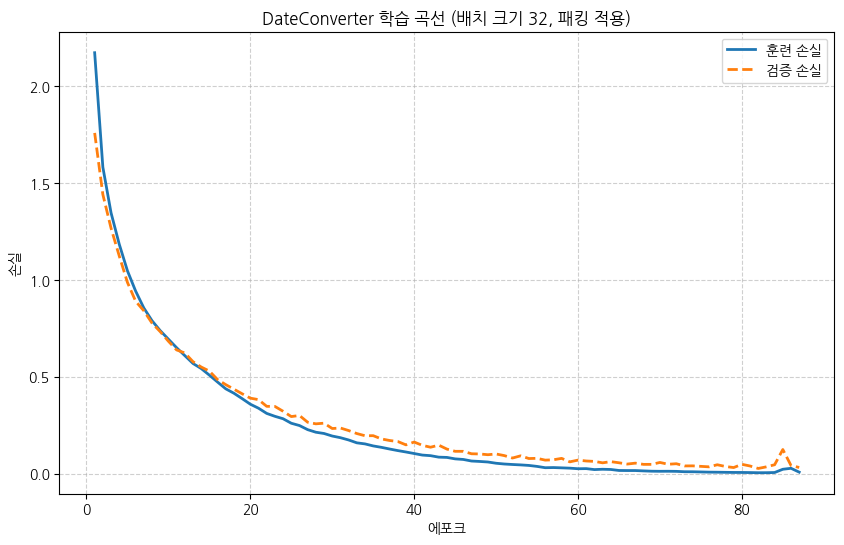

In [44]:
# 참고 - 학습 곡선 (EpochLogger 내장 plot, §7.7)
history['log'].plot(title='DateConverter 학습 곡선 (배치 크기 32, 패킹 적용)')

## 학습된 모델로 변환 결과 확인

미니 배치 모델은 한 샘플을 예측할 때도 `src_lengths`를 함께 전달해야 한다.

In [45]:
# 참고 - 미니 배치 학습 모델의 예측 함수
@torch.no_grad()
def predict(model, src_text, src_vocab, tgt_vocab, device=None, max_length=12):
    if device is None:
        device = torch.device('cpu')
    model.eval()
    src_ids = src_vocab.encode(src_text)
    src = torch.LongTensor(src_ids).unsqueeze(0).to(device)
    src_lengths = torch.LongTensor([len(src_ids)])  # 1샘플 예측에도 길이 정보 필요
    hidden, cell = model.encoder(src, src_lengths)
    context = hidden[-1].unsqueeze(1)
    tgt_token = torch.tensor([[SOS_IDX]]).to(device)
    result_ids = []
    for _ in range(max_length):
        logits, hidden, cell = model.decoder.forward_step(
            tgt_token, hidden, cell, context,
        )
        prediction = logits.argmax(dim=-1, keepdim=True)
        if prediction.item() == EOS_IDX:
            break
        result_ids.append(prediction.item())
        tgt_token = prediction
    return ''.join(tgt_vocab.decode(result_ids))


# 임의 날짜 하나를 여덟 형식으로 테스트
random.seed(SEED)
test_date = choice_random_dates(1) * 8
test_src, test_tgt = generate_datepairs(test_date)
print(f'정답 날짜 문자열: {test_tgt[0]}')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(test_src, test_tgt):
    pred = predict(model, src_text, src_vocab, tgt_vocab, device)
    mark = '정답' if pred == tgt_text else '오답'
    print(f'  {src_text:<40s} => {pred} ({mark})')

정답 날짜 문자열: 2014-9-25
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  25 September 2014                        => 2014-9-25 (정답)
  25 Sep 2014                              => 2014-9-25 (정답)
  September 25, 2014                       => 2014-9-25 (정답)
  Sep 25, 2014                             => 2014-9-25 (정답)
  09/25/2014                               => 2014-9-25 (정답)
  2014/09/25                               => 2014-9-25 (정답)
  25-09-2014                               => 2014-9-25 (정답)
  2014-09-25                               => 2014-9-25 (정답)


## 정리 ([표 9-3] 비교)

- 가변 길이 순차 데이터의 미니 배치 학습은 패딩 -> 배치 병합 함수 ->
  패킹 -> 언패킹의 4단계 표준 절차를 따른다.
- `pad_sequence()`, `pack_padded_sequence()`, `pad_packed_sequence()` 세
  함수가 각 단계의 도구이며, `CrossEntropyLoss(ignore_index=PAD_IDX)`로
  손실 계산에서 `<pad>` 위치를 제외한다.
- 미니 배치(배치 크기 32) 학습은 9-1절의 배치 크기 1 대비 에포크당 학습
  시간이 압도적으로 짧아 전체 학습이 훨씬 빨리 끝난다. 다만 같은 학습률에서
  최적 에포크에 도달하기까지 더 많은 에포크가 필요하다.

## 노이즈 데이터셋으로 미니 배치 재학습 (참고)

9-3절 `data.ipynb`의 노이즈 데이터 생성법으로, 입력 날짜 문자열 앞뒤에 무작위
문자를 덧붙인 최대 40자 입력을 만들어 미니 배치 방식으로 재학습한다. 어휘
사전·데이터셋·데이터로더·모델은 모두 새로(`_noisy`) 만들고, 미니 배치 구성
(`collate_fn`, 패킹)은 그대로 사용한다.

In [ ]:
# 참고 - 노이즈 데이터셋을 추가해 미니 배치로 재학습 (9-3절 data.ipynb 노이즈 생성법)
import string

# 노이즈 문자를 추가한 입력 문자열 생성 함수
def add_random_noise(text, max_length=40):
    # 날짜 문자열 앞뒤에 무작위 노이즈 문자를 덧붙여 최대 40자 입력을 만든다.
    noise_chars = (
        string.ascii_letters + string.digits + '!@#$%^&*()_+-=[]{}|;:,./<>?'
    )
    # 앞, 뒤에 추가할 노이즈 문자열
    prefix, suffix = '', ''
    remaining = max_length - len(text)
    if remaining > 0:
        prefix_length = random.randint(0, remaining)
        remaining -= prefix_length
        prefix = ''.join(random.choices(noise_chars, k=prefix_length))
    if remaining > 0:
        suffix_length = random.randint(0, remaining)
        suffix = ''.join(random.choices(noise_chars, k=suffix_length))
    return prefix + text + suffix

# 노이즈 문자열을 추가한 입력 날짜 문자열과 정답 날짜 문자열 리스트 생성 함수
def generate_noisy_datepairs(date_list, src_formats=src_formats):
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(add_random_noise(date.strftime(src_format)))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates


def show_sample_result(src_text, tgt_text, predicted_text):
    mark = '정답' if predicted_text == tgt_text else '오답'
    return f'  {src_text:<40s} => {predicted_text} ({mark})'


PATIENCE = 30
EPOCHS = 500

# 1) 노이즈 데이터셋 생성 (4,000쌍)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

date_list_noisy = choice_random_dates(4000)
src_dates_noisy, tgt_dates_noisy = generate_noisy_datepairs(date_list_noisy)
print('노이즈 데이터셋 예시:')
for i in range(2):
    print(f'  {src_dates_noisy[i]!r} -> {tgt_dates_noisy[i]!r}')

# 2) 노이즈 문자를 포함하도록 어휘 사전을 다시 생성 (<pad> 포함)
src_vocab_noisy = Vocab(src_dates_noisy, special_tokens)
tgt_vocab_noisy = Vocab(tgt_dates_noisy, special_tokens)
print(f'입력 어휘 사전 크기: {len(src_vocab)} -> {len(src_vocab_noisy)}')

# 3) 데이터셋과 데이터로더 (미니 배치 구성 collate_fn 재사용)
train_set_noisy = DateDataset(
    src_dates_noisy[:3000], tgt_dates_noisy[:3000], src_vocab_noisy, tgt_vocab_noisy)
valid_set_noisy = DateDataset(
    src_dates_noisy[3000:], tgt_dates_noisy[3000:], src_vocab_noisy, tgt_vocab_noisy)
train_loader_noisy = DataLoader(
    train_set_noisy, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_loader_noisy = DataLoader(
    valid_set_noisy, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# 4) 모델 재생성 후 재학습 (구조·하이퍼파라미터는 9-2절과 동일)
encoder_noisy = Encoder(len(src_vocab_noisy), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
decoder_noisy = Decoder(len(tgt_vocab_noisy), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
model_noisy = DateConverter(encoder_noisy, decoder_noisy).to(device)

optimizer_noisy = optim.Adam(model_noisy.parameters(), lr=LR)
history_noisy = train_loop(
    model_noisy, train_loader_noisy, valid_loader_noisy, criterion, optimizer_noisy,
    epochs=EPOCHS, patience=PATIENCE, device=device,
)

# 5) 변환 결과 - 노이즈 없는 입력과 노이즈 추가 입력 비교 (같은 날짜)
random.seed(SEED)
test_date = choice_random_dates(1) * 8
clean_src, clean_tgt = generate_datepairs(test_date)
noisy_src, noisy_tgt = generate_noisy_datepairs(test_date)

print(f'\n정답 날짜 문자열: {clean_tgt[0]}')
print('노이즈 없는 날짜 문자열 변환:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(clean_src, clean_tgt):
    pred = predict(model_noisy, src_text, src_vocab_noisy, tgt_vocab_noisy, device)
    print(show_sample_result(src_text, tgt_text, pred))

print('\n노이즈를 추가한 날짜 문자열 변환:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(noisy_src, noisy_tgt):
    pred = predict(model_noisy, src_text, src_vocab_noisy, tgt_vocab_noisy, device)
    print(show_sample_result(src_text, tgt_text, pred))

노이즈 데이터셋 예시:
  'uKq5Mc2r0I!s%)25 September 2014Z' -> '2014-9-25'
  ']qDOx[U4120E=2_!A2hlkBq9T24 Dec 19191ZL' -> '1919-12-24'
입력 어휘 사전 크기: 43 -> 93
  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/500       2.2359       1.8323        0.00%     0:02
  2/500       1.6806       1.5815        0.00%     0:04
  3/500       1.4987       1.4372        0.00%     0:05
  4/500       1.3713       1.3046        0.00%     0:07
  5/500       1.2810       1.2383        0.00%     0:09
  6/500       1.2111       1.1844        0.00%     0:11
  7/500       1.1696       1.1548        0.00%     0:12
  8/500       1.1267       1.1220        0.00%     0:14
  9/500       1.1052       1.0834        0.10%     0:16
 10/500       1.0758       1.0667        0.00%     0:18
 11/500       1.0413       1.0329        0.10%     0:20
 12/500       1.0034       1.0066        0.20%     0:22
 13/500       0.9768       0.9520        0.20%     0:24
 14/500       0.9370       0.9536        0.20%     0:25
 15/500       0.9140      